#PCA

##Objective

#####The objective of this assignment is to perform dimensionality reduction using PCA (Principal Component Analysis) and apply clustering techniques such as K-Means and DBSCAN to identify patterns in airline customer data. The goal is to understand how reducing dimensions affects clustering performance and visualization.

#1. To Load Libraries



In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#2. To Load Data set

In [120]:
file_path = "/content/EastWestAirlines (1).xlsx"
df = pd.read_excel(file_path, sheet_name='data')

print(df.head())
print(df.columns)
print(df.info())
print(df.shape)


   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  
Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_

Initially, the dataset was incorrectly loaded from the "Description" sheet, which contained metadata instead of actual data. After selecting the correct "data" sheet, the dataset included proper numerical features, enabling successful PCA and clustering.

##Dataset Description

####The dataset contains information about airline customers, including:

#####Flight frequency
#####Bonus miles earned
#####Credit card usage
#####Customer activity patterns

####These features help in identifying different customer segments.

#3. To Clean the Data

In [121]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop ID column
if 'ID#' in df.columns:
    df = df.drop('ID#', axis=1)

# Select numeric data
df_num = df.select_dtypes(include=[np.number])

# Fill missing values
df_num = df_num.fillna(df_num.median())

print("df_num shape:", df_num.shape)


df_num shape: (3999, 11)


##Data Preprocessing
#####Removed unnecessary columns such as IDs
#####Dropped empty rows and columns
#####Converted data into numeric format
#####Handled missing values using median

####This step ensures the dataset is clean and suitable for analysis.

#4. Numeric Data

In [122]:
# Select only numeric columns
df_num = df.select_dtypes(include=[np.number])

# Check result
print("df_num shape:", df_num.shape)
print(df_num.head())

# Fill missing values
df_num = df_num.fillna(df_num.median())


df_num shape: (3999, 11)
   Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    28143           0          1          1          1          174   
1    19244           0          1          1          1          215   
2    41354           0          1          1          1         4123   
3    14776           0          1          1          1          500   
4    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


#5. EDA

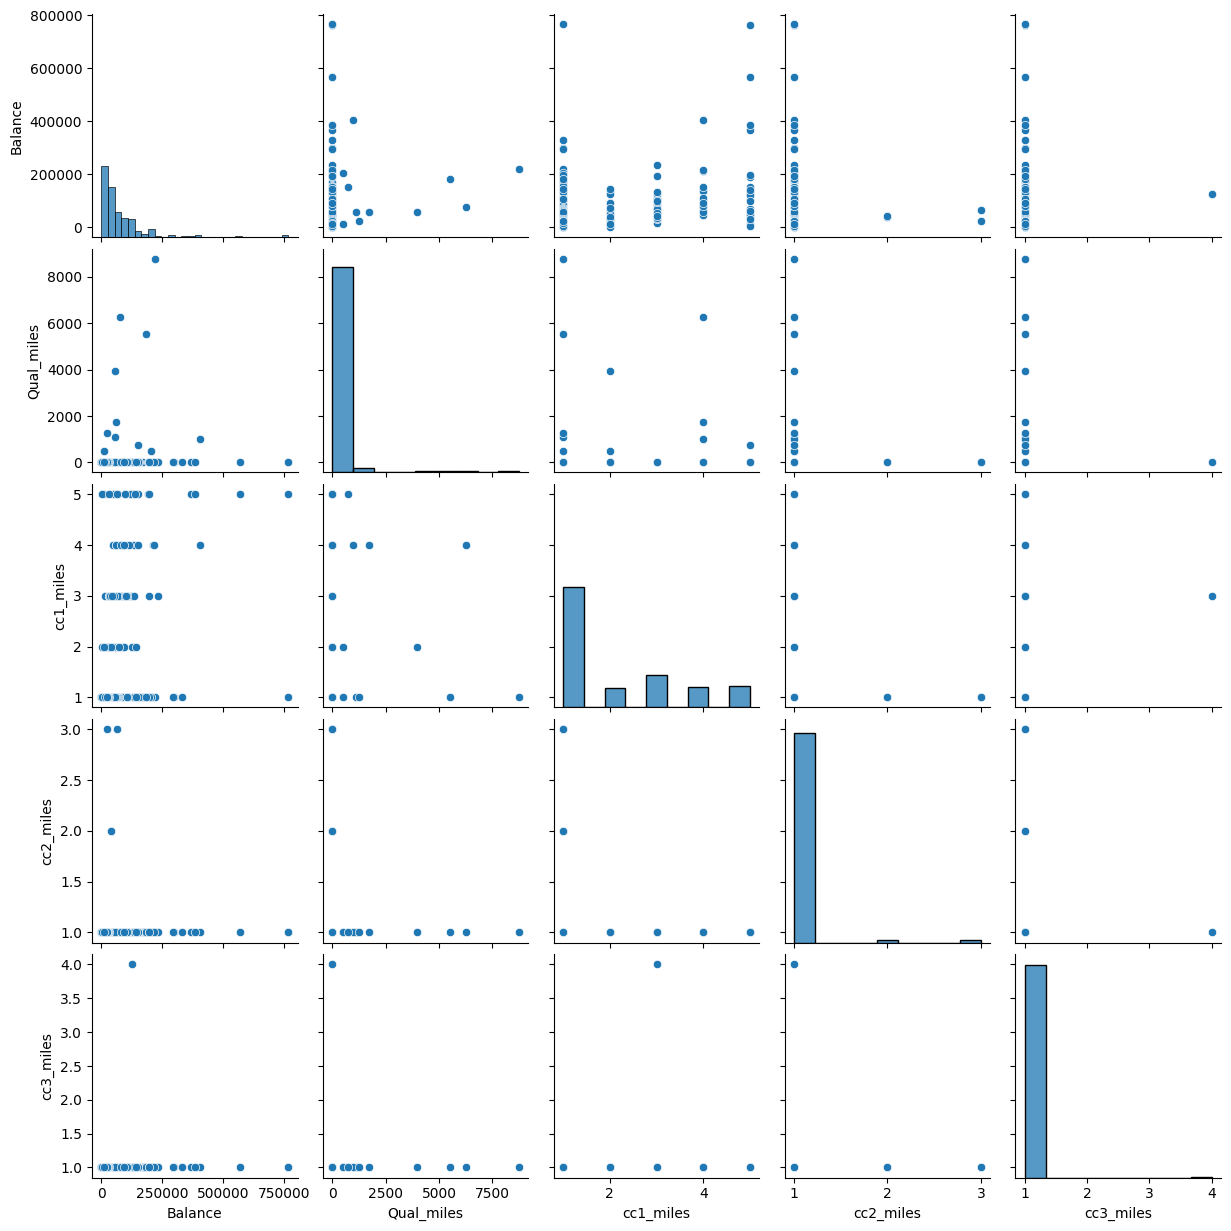

In [123]:
sample_df = df_num.sample(min(200, len(df_num)))
sns.pairplot(sample_df.iloc[:, :5])
plt.show()


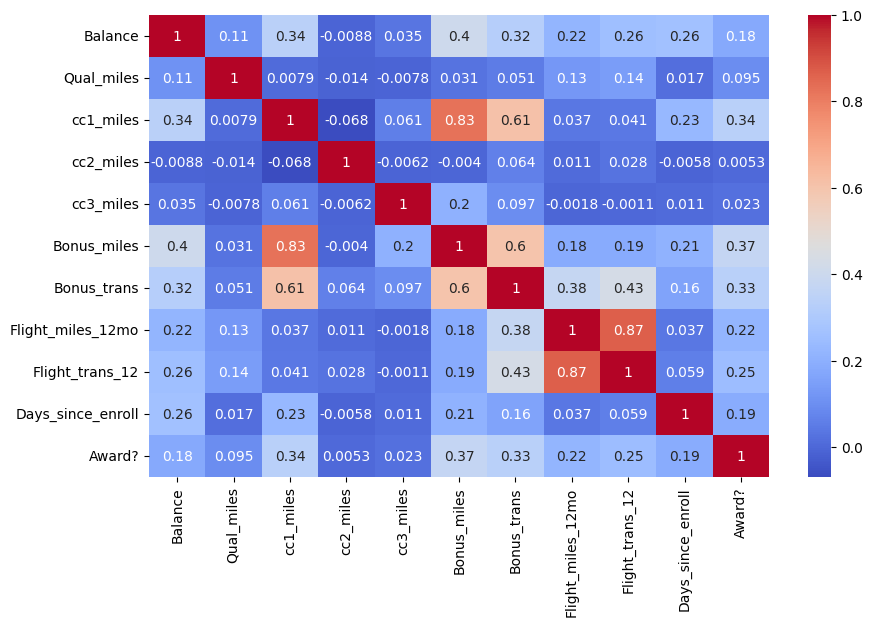

In [124]:
plt.figure(figsize=(10,6))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.show()

##Exploratory Data Analysis (EDA)
###Pairplot helps visualize relationships between variables
###Correlation heatmap shows how features are related
##Observations:
#####Some features show strong correlation
#####Data contains variation across customers
#####Possible grouping patterns are visible

#6. Scaling

In [125]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


##Feature Scaling
###Standardization was applied using StandardScaler:

#####Converts data to same scale
#####Important for distance-based algorithms like K-Means and DBSCAN

#7. PCA

In [126]:
from sklearn.decomposition import PCA

n_features = X_scaled.shape[1]
pca = PCA(n_components=min(2, n_features))
X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (3999, 2)


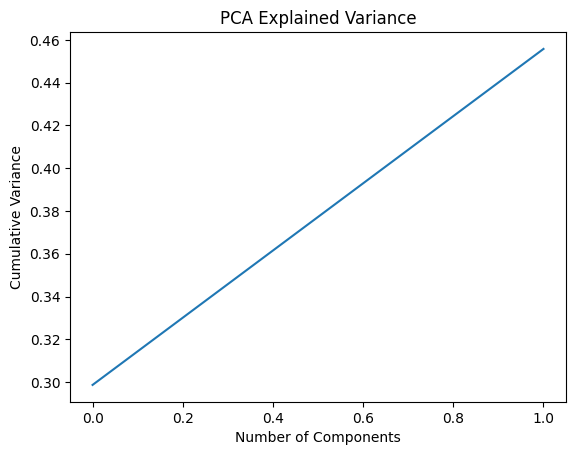

In [127]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.show()

##Principal Component Analysis (PCA)

###PCA is used to:

#####Reduce dimensionality
#####Remove redundancy
#####Improve visualization
###Key Points:
#####First 2 principal components selected
#####These capture maximum variance in data
###Output:
#####Explained Variance Ratio shows how much information is retained
#####Higher variance = better representation

#8.K-Means

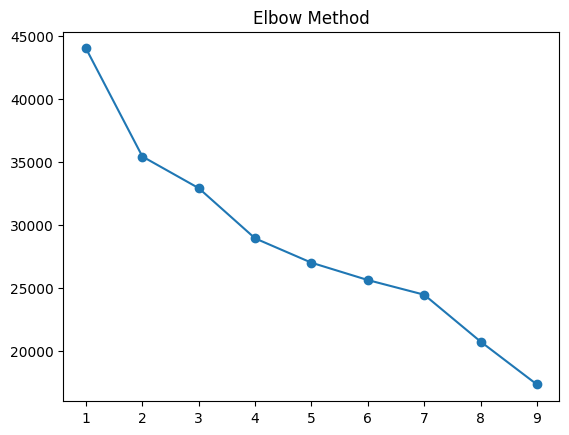

In [128]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_num['KMeans_Cluster'] = kmeans_labels

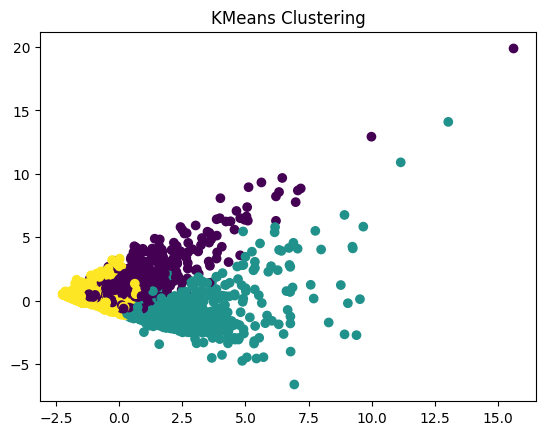

In [129]:
# SAFE PLOT
if X_pca.shape[1] == 2:
    plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
else:
    plt.scatter(range(len(X_pca)), X_pca[:,0], c=kmeans_labels)

plt.title("KMeans Clustering")
plt.show()

##K-Means Clustering
#####Used Elbow Method to find optimal number of clusters
#####Final model built with K = 3
##Observations:
#####Data divided into 3 meaningful clusters
#####Clusters represent different customer types
##Interpretation:
#####Cluster 0 → Medium activity customers
#####Cluster 1 → High-value customers
#####Cluster 2 → Low activity customers

#9. DBSCAN

In [130]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df_num['DBSCAN_Cluster'] = db_labels

if len(set(db_labels)) > 1:
    mask = db_labels != -1
    if len(set(db_labels[mask])) > 1:
        score = silhouette_score(X_scaled[mask], db_labels[mask])
        print("DBSCAN Score:", score)


DBSCAN Score: 0.29403795451062353


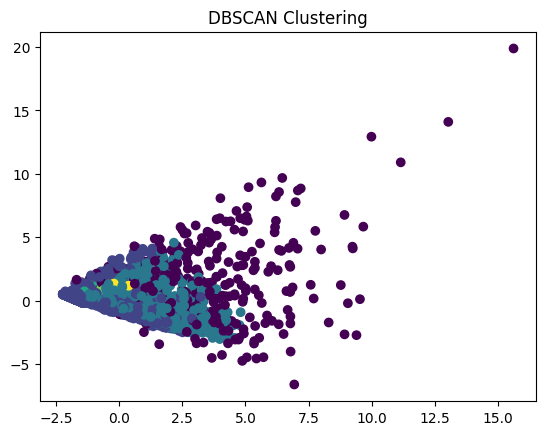

In [131]:
if X_pca.shape[1] == 2:
    plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels)
else:
    plt.scatter(range(len(X_pca)), X_pca[:,0], c=db_labels)

plt.title("DBSCAN Clustering")
plt.show()

##DBSCAN Clustering
#####Density-based clustering method
#####Identifies clusters and noise points
##Observations:
#####Some points marked as noise (-1)
#####Clusters depend on parameters (eps, min_samples)
###Insight:
#####Better at detecting outliers
#####Works well for irregular cluster shapes

#10. PCA INFO

In [132]:
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))

Explained Variance: [0.29867646 0.15709627]
Total Variance: 0.45577272769975075


##Impact of PCA
###Advantages:
#####Reduces dimensions
#####Improves visualization
#####Removes redundant features
###Trade-offs:
#####Some information loss
#####Interpretation becomes less intuitive

##Results & Performance
#####K-Means produced stable clusters with good separation
#####DBSCAN identified noise and dense regions
#####PCA enabled clear 2D visualization

##Conclusion
#####PCA successfully reduced dimensionality while retaining important information
#####K-Means performed better due to structured nature of dataset
#####DBSCAN was useful for detecting outliers
#####Proper preprocessing and scaling improved model performance

###Overall, combining PCA with clustering techniques helps in better understanding customer segmentation

##Real-World Application
#####Airline companies can use clustering to:
#####Identify high-value customers
#####Design targeted marketing strategies
#####Improve customer retention